# Tarea 01: Aproximación de una función desconocida

Generamos datos con una función que **nosotros definimos y ustedes no conocen**. Su
trabajo es reconstruirla a partir de los datos.

No es un acertijo: es lo que hace el machine learning todos los días. El capítulo 02
plantea el aprendizaje como **aproximación de funciones**, y aquí van a hacer
exactamente eso, con la ventaja rara de que existe una respuesta correcta y un límite
teórico al que se puede llegar.

## Lo que hay

- `train.csv`: 800 observaciones con 12 variables (`x1` a `x12`) y la respuesta `y`.
- `test.csv`: 400 observaciones con las mismas 12 variables, **sin** `y`.

Entregan sus 400 predicciones y un bot las califica automáticamente.

## Cómo se califica

| Su MSE en el conjunto de prueba | Calificación |
|---|---|
| Igual o peor que una regresión lineal con las 12 variables crudas | **5.0** |
| Igual al modelo bien especificado (el error irreducible) | **10.0** |
| En medio | proporcional a la mejora |

**El 5 está garantizado si entregan algo que corre.** El código del baseline se lo damos
hecho más abajo; de ahí para arriba es mérito suyo.

Tienen **3 intentos** de calificación. Un comentario `/validar` revisa el formato y les
dice cuál es su MSE objetivo **sin gastar intento**, así que úsenlo antes del primero.

## Qué se evalúa además del MSE

El MSE es la mitad. La otra mitad es la **Parte 5: la bitácora**, donde documentan cada
hipótesis que probaron — incluidas las que fallaron. Un notebook con buen MSE y bitácora
vacía vale poco: significa que no entendieron por qué funcionó.

---

## Las reglas sobre la IA

**Sí pueden usar IA. De hecho quiero que la usen.** Pero de una forma específica.

La IA no puede ver sus datos. Puede explicarles teoría, listarles técnicas o decirles qué
función de `matplotlib` usar. Lo que **no** puede hacer es mirar una gráfica de residuales
y decirles qué término falta, porque eso solo lo revela correr el código con *sus* datos, y
cada quien tiene datos distintos.

Así que la IA es su tutor, no su chofer. Para que sea tutor, péguenle esto al inicio de
cada conversación:

> Eres mi tutor de regresión, no mi resolvedor. Reglas: (1) no escribes código que yo
> pueda copiar; si te pido código, me devuelves el nombre de la función y su docstring.
> (2) No me das la respuesta: me preguntas qué espero ver y por qué. (3) Cuando me
> equivoque, no me corriges: me sugieres qué gráfica revelaría mi error. (4) Máximo
> tres oraciones por respuesta.

Y una regla para ustedes: **si la IA les da código y no pueden explicar qué hace línea
por línea, bórrenlo y escríbanlo ustedes.** Se nota en la bitácora, y se nota más en el
examen.

---
## Parte 0. Su variante

Cada quien tiene **datos distintos**: las 12 variables juegan papeles diferentes según
la persona. Copiar las predicciones de alguien más da un MSE malísimo. Comparar
*métodos* entre ustedes, en cambio, es buena idea y se los recomiendo.

Su carpeta de datos se identifica con su **clave única del ITAM**.

In [2]:
import hashlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 110
SEMILLA = 42

In [3]:
# TODO: pongan su clave única del ITAM (con o sin ceros a la izquierda, da lo mismo)
CLAVE_UNICA = "214430"

# De la clave sale el nombre de su carpeta. No lo cambien a mano.
_clave = "".join(c for c in CLAVE_UNICA if c.isdigit()).zfill(9)
CARPETA = "v" + hashlib.sha256(_clave.encode()).hexdigest()[:8]

# Funciona corriendo el notebook desde `tareas/` o desde la raíz del repo
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "tareas/tarea_01_datos").exists())
MIS_DATOS = RAIZ / "tareas/tarea_01_datos" / CARPETA

assert CLAVE_UNICA, "Escriban su clave única en CLAVE_UNICA."
assert MIS_DATOS.exists(), (
    f"No existe la carpeta {CARPETA}. Revisen su clave única: si está mal escrita, "
    f"el nombre de la carpeta sale distinto y no van a encontrar sus datos."
)

train = pd.read_csv(MIS_DATOS / "train.csv")
test = pd.read_csv(MIS_DATOS / "test.csv")

VARIABLES = [f"x{i}" for i in range(1, 13)]
print(f"Su variante: {CARPETA}")
print(f"train: {train.shape}   test: {test.shape}")
train.head()

Su variante: v67e9ec7a
train: (800, 13)   test: (400, 12)


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,y
0,0.214155,1.390304,0.170116,1.119986,0.707775,1.996171,2.365967,1.489694,32.420571,-1.269936,0.391091,-0.134001,31.267338
1,0.152242,1.131811,-0.118278,2.877838,0.802716,-0.140802,-0.461219,-0.006143,11.669437,-0.596547,0.178812,-2.091088,-6.776922
2,1.021906,-1.193502,-0.192995,0.613706,8.147668,-1.879427,0.200818,2.329083,18.292502,-0.664372,0.417161,2.590257,27.877896
3,1.780869,0.317572,-0.284673,0.325806,1.273832,-1.730625,1.418816,2.168514,58.795095,-0.039202,0.131093,0.401227,26.328440
4,0.105895,-1.220792,0.370353,1.558350,3.627891,-1.995860,0.071560,2.593989,95.299136,-2.152092,-0.482576,1.474227,0.298131


In [4]:
# TODO: primer vistazo. ¿Qué rangos tienen las variables? ¿Hay faltantes?
train.describe().T

,count,mean,std,min,25%,50%,75%,max
x1,800.0,1.700432,2.762078,0.057254,0.482264,0.923515,1.958116,35.560016
x2,800.0,0.027212,1.149180,-1.988222,-0.933366,0.078200,1.050389,1.994246
x3,800.0,0.006173,0.291131,-0.499953,-0.253973,0.005350,0.270208,0.499500
x4,800.0,2.032085,1.161090,0.005388,1.074290,2.023120,3.075366,3.998754
x5,800.0,1.710882,2.314216,0.045148,0.497694,1.024526,2.122825,37.338990
x6,800.0,-0.012239,1.201530,-1.998153,-1.062693,-0.041399,0.991899,1.999542
x7,800.0,-0.058879,0.974642,-3.534641,-0.681603,-0.001625,0.557212,3.336942
x8,800.0,0.064585,1.730576,-2.964392,-1.442540,0.027071,1.619454,2.992505
x9,800.0,49.429430,29.188983,0.019125,21.912854,49.612553,75.375986,99.292487
x10,800.0,-0.026041,0.988104,-3.111189,-0.690747,-0.033044,0.643610,2.627031


### 0.1 El baseline que hay que ganar

Este es el modelo de referencia: una regresión lineal con las 12 variables **tal como
vienen**, sin transformar nada. Su MSE sobre el conjunto de prueba es, por definición, la
calificación **5.0**.

Se lo damos corrido para que arranquen sabiendo exactamente qué hay que superar.

In [5]:
X_train, X_val, y_train, y_val = train_test_split(
    train[VARIABLES], train["y"], test_size=0.25, random_state=SEMILLA
)

baseline = LinearRegression().fit(X_train, y_train)
mse_baseline = mean_squared_error(y_val, baseline.predict(X_val))

print(f"MSE del baseline en validación: {mse_baseline:.2f}")
print(f"R² del baseline en validación : {baseline.score(X_val, y_val):.3f}")
print(f"\nDesviación estándar de y: {train['y'].std():.2f}")

MSE del baseline en validación: 111.04
R² del baseline en validación : 0.295

Desviación estándar de y: 12.89


### 0.2 Cómo medir su progreso sin gastar intentos

Solo tienen 3 calificaciones, y necesitan medirse muchas más veces que eso. La solución
es la de siempre: **partir `train` en entrenamiento y validación**, ajustar en una parte
y medir en la otra. Eso ya lo hicimos en la celda anterior.

Dos advertencias importantes:

- Su MSE de validación **no** va a coincidir exactamente con el oficial. El oficial se
  mide sobre `test.csv`, que son otras 400 observaciones. Su número es una *estimación*
  del oficial, con su propia incertidumbre.
- Si eligen entre muchos modelos usando el mismo conjunto de validación, van a
  sobreajustar la validación. Para decisiones finas, usen validación cruzada
  (`cross_val_score`) en lugar de una sola partición.

**Nunca** ajusten nada usando `test.csv`: no tiene `y`, así que ni podrían — y ese es
justo el punto.

---
## Parte 1. Exploración

Antes de modelar, mírenlos. El objetivo de esta parte **no** es encontrar la respuesta,
es formarse sospechas que después van a confirmar o descartar.

Tres cosas que vale la pena graficar:

1. La distribución de cada variable por separado.
2. `y` contra cada variable, una gráfica por variable.
3. La matriz de correlación.

array([[<Axes: title={'center': 'x1'}>, <Axes: title={'center': 'x2'}>,
        <Axes: title={'center': 'x3'}>],
       [<Axes: title={'center': 'x4'}>, <Axes: title={'center': 'x5'}>,
        <Axes: title={'center': 'x6'}>],
       [<Axes: title={'center': 'x7'}>, <Axes: title={'center': 'x8'}>,
        <Axes: title={'center': 'x9'}>],
       [<Axes: title={'center': 'x10'}>, <Axes: title={'center': 'x11'}>,
        <Axes: title={'center': 'x12'}>]], dtype=object)

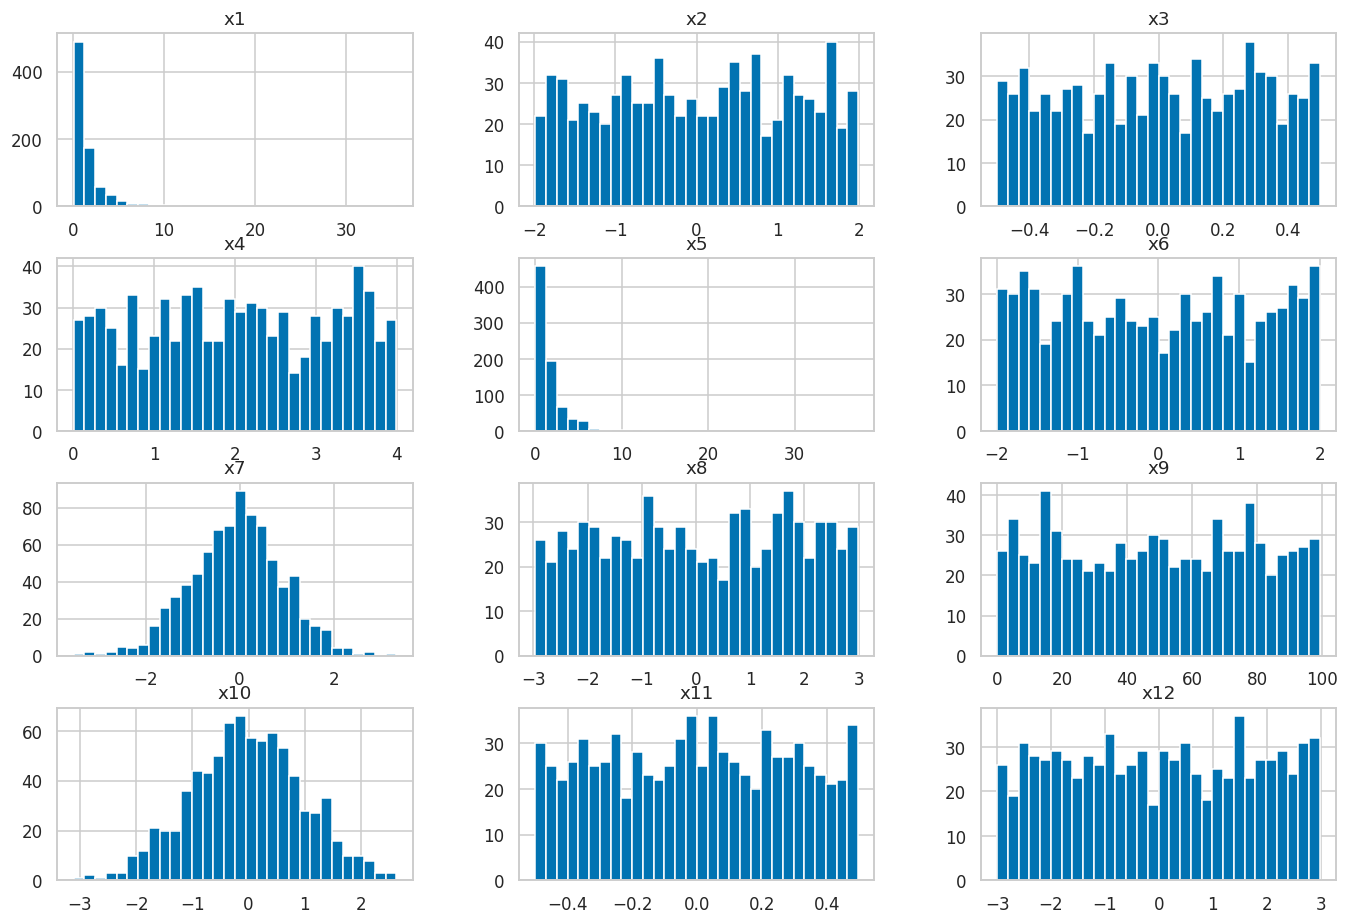

In [6]:
# TODO: distribución de cada una de las 12 variables.
# Pista de método: `train[VARIABLES].hist(...)` hace las 12 de un golpe.
train[VARIABLES].hist(bins=30, figsize=(15, 10))

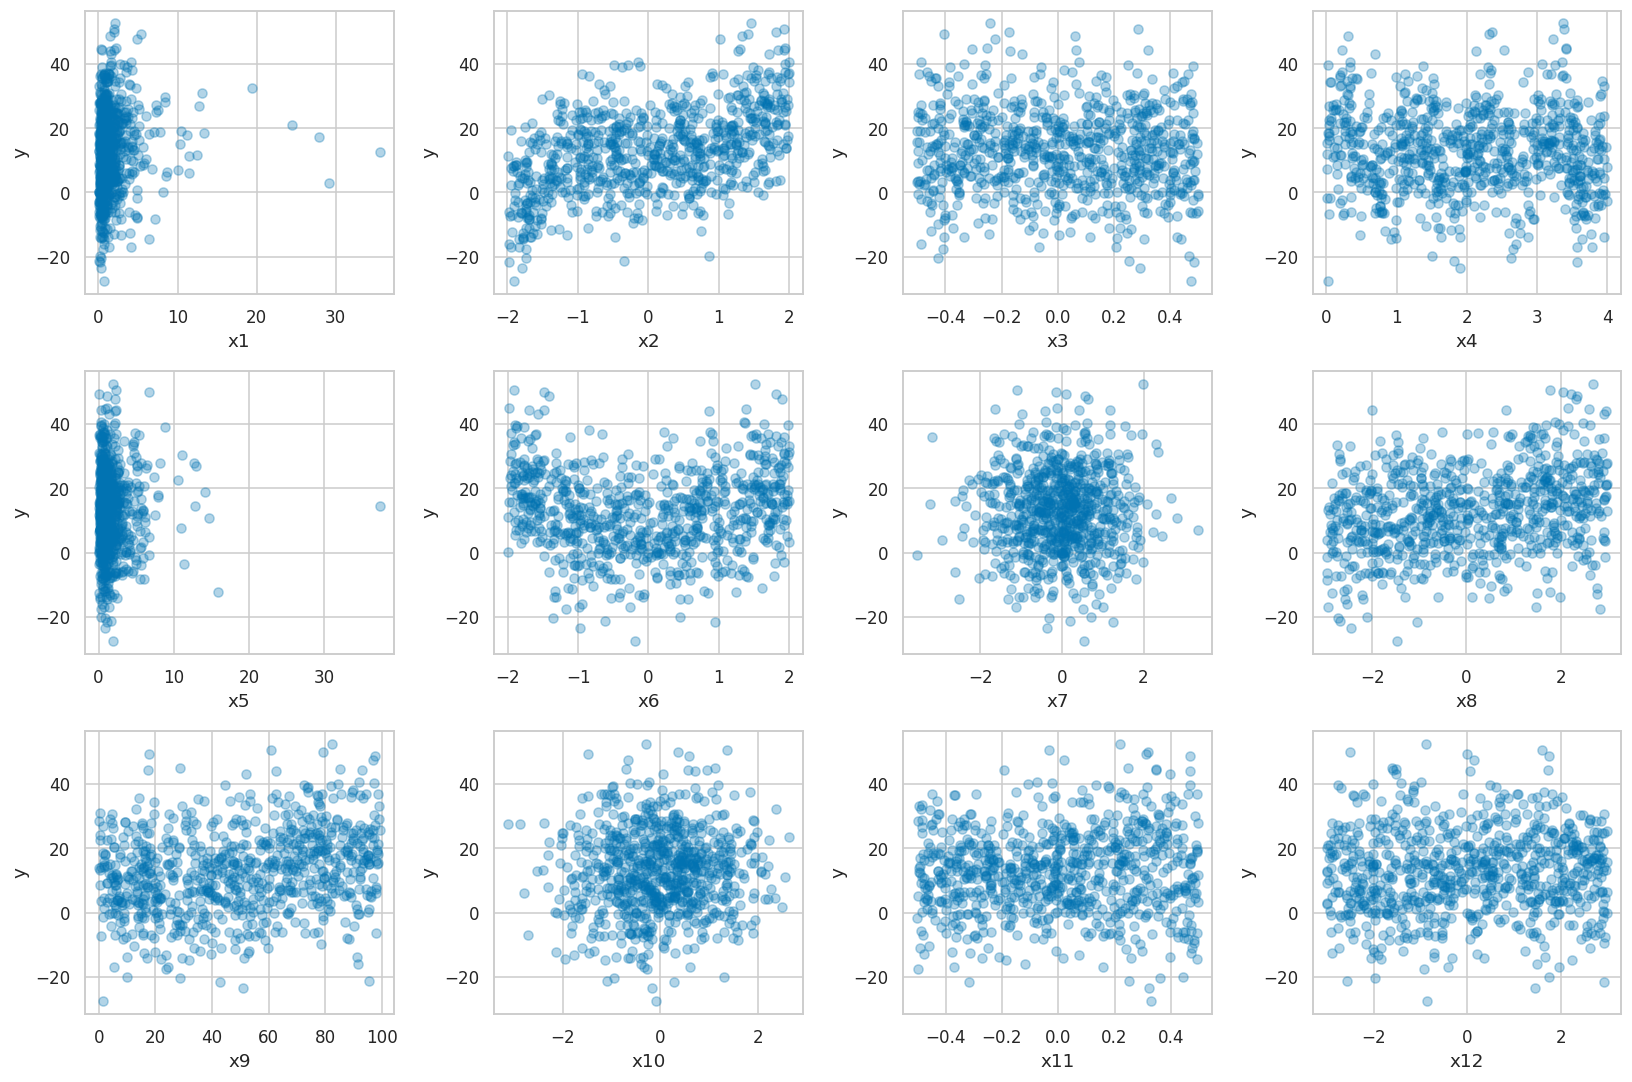

x6 tiene forma de u, aunque su correlación es baja. Pues la correlación solo detecta relaciones lineales.
x1 y x5 muestran valores cercanos a 0


In [7]:
# TODO: `y` contra cada variable. Una rejilla de 12 paneles.
# Usen puntos con transparencia (`alpha`): con 800 observaciones se traslapan.
plt.figure(figsize=(15, 10))

for i, variable in enumerate(VARIABLES):
    panel = plt.subplot(3, 4, i + 1)
    panel.scatter(train[variable], train["y"], alpha=0.3)
    panel.set_xlabel(variable)
    panel.set_ylabel("y")
    panel.grid(True)

plt.tight_layout()
plt.show()
print("x6 tiene forma de u, aunque su correlación es baja. Pues la correlación solo detecta relaciones lineales.")
print("x1 y x5 muestran valores cercanos a 0")

In [8]:
# TODO: matriz de correlación entre las 12 variables y `y`.
dataframe=pd.concat([train[VARIABLES], train["y"]], axis=1)
dataframe.corr()

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,y
x1,1.000000,-0.021250,-0.034285,-0.012337,-0.003288,0.031294,-0.046157,-0.020691,-0.008917,0.060346,-0.019161,0.017363,0.093026
x2,-0.021250,1.000000,-0.007604,-0.018343,-0.044299,0.021968,0.001821,0.014677,0.002789,0.019527,0.026980,-0.035210,0.489361
x3,-0.034285,-0.007604,1.000000,0.022686,0.027107,-0.053121,0.049304,-0.032693,-0.010593,-0.046859,-0.016389,-0.019484,-0.057988
x4,-0.012337,-0.018343,0.022686,1.000000,-0.028841,-0.003397,0.058891,0.015938,-0.010873,0.023691,-0.033361,0.024692,-0.078910
x5,-0.003288,-0.044299,0.027107,-0.028841,1.000000,0.025587,-0.018577,0.101233,-0.017083,-0.033679,-0.021356,0.055344,0.020188
x6,0.031294,0.021968,-0.053121,-0.003397,0.025587,1.000000,-0.070098,-0.057277,0.014070,0.019792,-0.012676,0.006320,0.022729
x7,-0.046157,0.001821,0.049304,0.058891,-0.018577,-0.070098,1.000000,0.022671,-0.021612,0.014426,-0.004888,-0.031779,0.013633
x8,-0.020691,0.014677,-0.032693,0.015938,0.101233,-0.057277,0.022671,1.000000,0.023618,0.011536,0.061272,-0.014580,0.281722
x9,-0.008917,0.002789,-0.010593,-0.010873,-0.017083,0.014070,-0.021612,0.023618,1.000000,0.035664,0.019592,-0.006722,0.262064
x10,0.060346,0.019527,-0.046859,0.023691,-0.033679,0.019792,0.014426,0.011536,0.035664,1.000000,-0.025508,-0.002357,0.044694


### 1.1 Registren sus sospechas ahora

Llenen esta tabla **antes** de seguir. Va a ser incómoda de llenar y eso es intencional:
la parte que enseña es volver a leerla al final y ver en qué se equivocaron.

| Variable | ¿Qué sospecho? | ¿En qué gráfica lo vi? | ¿Qué tan seguro estoy? |
|---|---|---|---|
| `x1` | | | |
| `x2` | | | |
| `x3` | | | |
| `x4` | | | |
| `x5` | | | |
| `x6` |Patrón en residuales |Residuales |Algo segura |
| `x7` | | | |
| `x8` | | | |
| `x9` | | | |
| `x10` | | | |
| `x11` | | | |
| `x12` | | | |

---
## Parte 2. La escalera de residuales

Este es el método central de la tarea, y el que quiero que se lleven de por vida.

Un **residual** es lo que su modelo no logró explicar: `residual = y - ŷ`. Si su modelo
capturó todo lo que había, los residuales deben ser **ruido**: sin forma, sin patrón, sin
estructura. Si al graficar los residuales contra una variable se ve una *forma*, esa
forma es un pedazo de la función que les falta — y la forma les dice qué término agregar.

El ciclo es siempre el mismo:

1. Ajustan el modelo que tienen.
2. Grafican los residuales contra **cada** variable.
3. Si alguna gráfica tiene forma, agregan un término que capture esa forma.
4. Vuelven al paso 1.

Paran cuando ya ninguna gráfica tiene forma, o cuando el MSE deja de bajar.

### ¿Y qué término agrego?

Eso es exactamente lo que tienen que descubrir, y es el trabajo de la tarea.

Lo que sí les conviene es pedirle a su IA el **catálogo**: "¿qué transformaciones existen
para linealizar una relación no lineal?", "¿cómo se modela un efecto que cambia de golpe
a partir de cierto valor?". Eso es conocimiento general y la IA lo tiene completo.

Cuál de esas transformaciones aplica, a cuál de sus doce variables y con qué parámetro,
no se lo puede decir nadie: solo su gráfica. Ahí es donde se aprende.

In [9]:
def ajusta(columnas_extra=None):
    """Ajusta una lineal con las 12 crudas más las columnas derivadas que le pasen.

    `columnas_extra` es un dict {nombre: función que recibe un DataFrame y devuelve
    una Serie}. Así el mismo término se construye igual en train, validación y test,
    que es donde se equivoca todo el mundo.

    Devuelve (modelo, mse_validacion, residuales_de_validacion, constructor).
    """
    columnas_extra = columnas_extra or {}

    def construye(df):
        salida = df[VARIABLES].copy()
        for nombre, f in columnas_extra.items():
            salida[nombre] = f(df)
        return salida

    modelo = LinearRegression().fit(construye(X_train), y_train)
    pred_val = modelo.predict(construye(X_val))
    mse = mean_squared_error(y_val, pred_val)
    return modelo, mse, y_val - pred_val, construye


modelo, mse, residuales, _ = ajusta()
print(f"Modelo con las 12 crudas -> MSE de validación {mse:.2f}")

Modelo con las 12 crudas -> MSE de validación 111.04


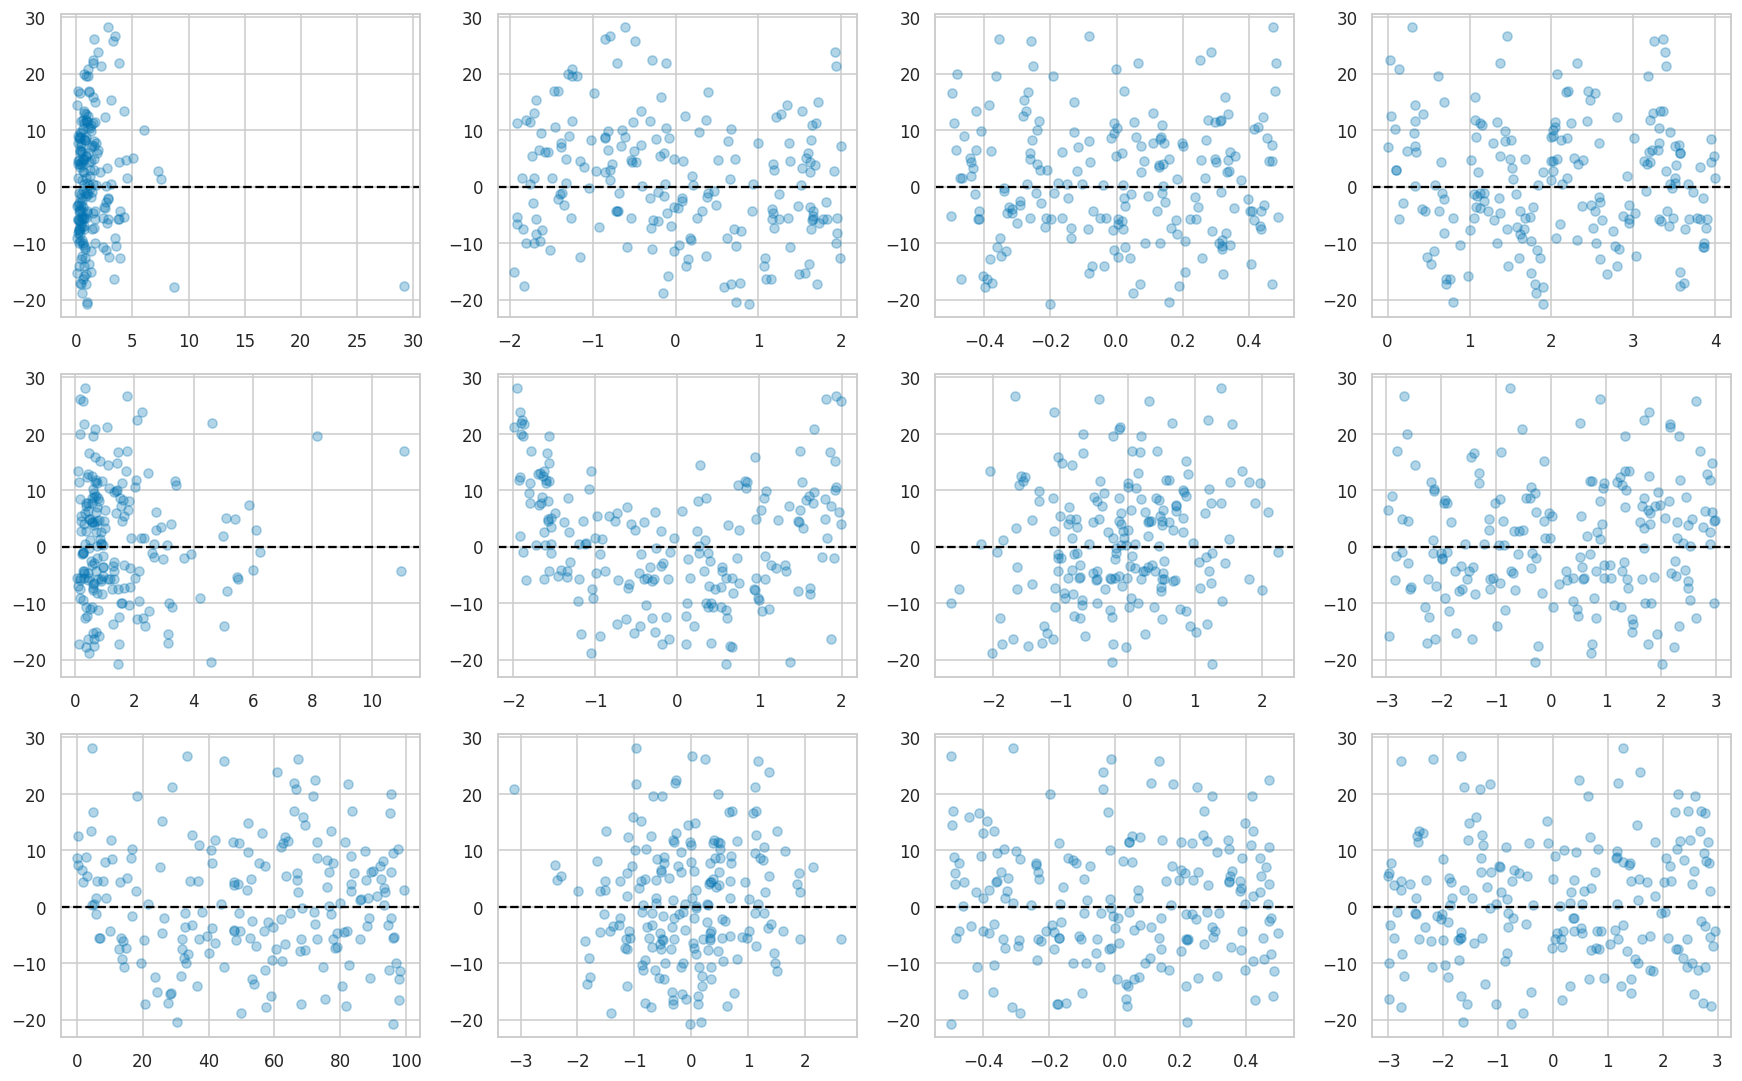

x6 muestra un claro patrón en sus residuales


In [10]:
# TODO: grafiquen los residuales contra cada una de las 12 variables.
# Una rejilla de 12 paneles, y en cada uno una línea horizontal en 0 como referencia.
#
# Lo que buscan es FORMA, no dispersión. Una nube gruesa sin patrón está bien;
# una nube que sube, baja, ondula o salta es un término que les falta.
plt.figure(figsize=(16, 10))

for i, variable in enumerate(VARIABLES):
    plt.subplot(3, 4, i + 1) #crea la rejilla de 3x4 paneles
    plt.scatter(X_val[variable], residuales, alpha=0.3)
    plt.axhline(0, color="black", linestyle="--")
    plt.grid(True)

plt.tight_layout()
plt.show()
print("x6 muestra un claro patrón en sus residuales")

1 MSE con x6²: 72.88
Hipótesis: faltaba una curvatura en x6.
Gráfica: residuales contra x6, con forma de U.
Término: x6_cuadrado = x6².
MSE: [111.04] -> [72.88].Origen: observación propia.


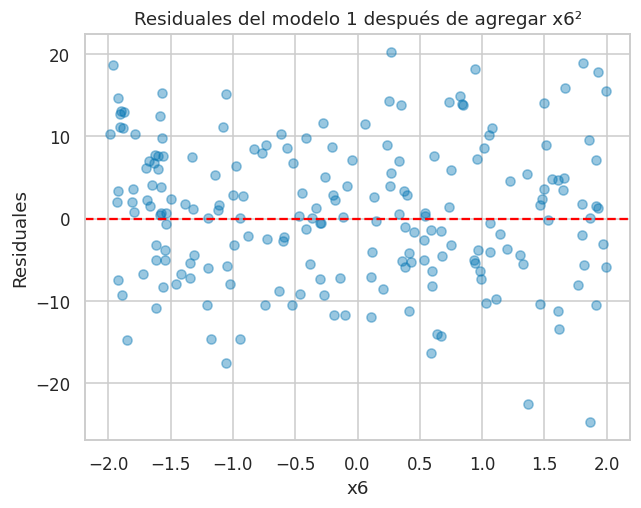

In [11]:
# TODO: agreguen su primer término y vuelvan a medir.
#
# Así se le pasa una columna derivada a `ajusta`. El término del ejemplo es deliberadamente
# absurdo y NO sirve para nada: solo ilustra la sintaxis del diccionario y del lambda.
#
# modelo, mse, residuales, _ = ajusta({"disparate": lambda d: d["x1"] + d["x2"]})
# print(f"MSE: {mse:.2f}")
#
# Si el MSE bajó mucho, iban bien. Si no se movió, ese término no era. Anoten las dos
# cosas en la bitácora: los intentos fallidos también cuentan.
# Cambio 1
modelo_1, mse_1, residuales_1, _ = ajusta({
    "x6_cuadrado": lambda d: d["x6"] ** 2
})

print(f"1 MSE con x6²: {mse_1:.2f}")
print("Hipótesis: faltaba una curvatura en x6.")
print("Gráfica: residuales contra x6, con forma de U.")
print("Término: x6_cuadrado = x6².")
print("MSE: [111.04] -> [72.88].Origen: observación propia.")

plt.scatter(X_val["x6"], residuales_1, alpha=0.4)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("x6")
plt.ylabel("Residuales")
plt.title("Residuales del modelo 1 después de agregar x6²")
plt.grid(True)
plt.show()

2 MSE con x6^2 y x2^3: 63.63
Hipótesis: faltaba una curvatura en x2.
Gráfica: residuales contra x2, con forma de s volteada.
Término: x2_cubo = x2^3.
MSE: [72.88] -> [63.63].Origen: observación propia.


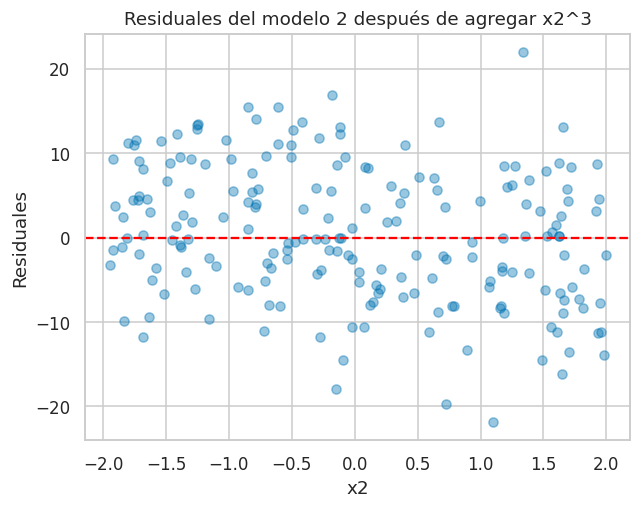

3 MSE con x6^2, x2^3 y x9^3: 64.57
Hipótesis: faltaba una curvatura en x9.
Gráfica: residuales contra x9, con forma de s volteada.
Término: x9_cubo = x9^3.
MSE: [63.63] -> [64.57].Origen: observación propia.


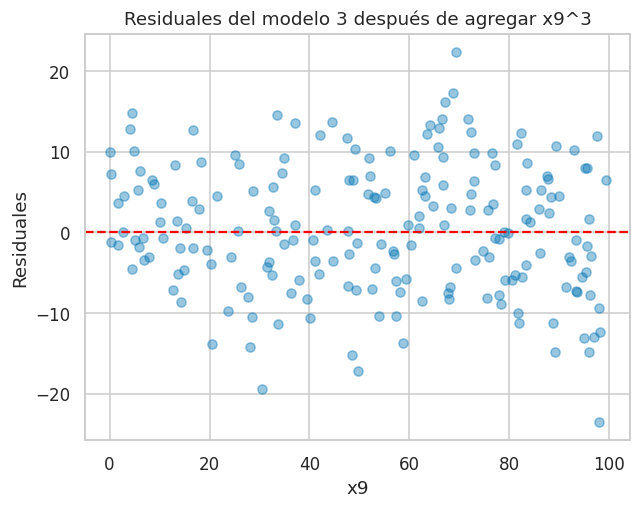

4 MSE con x6^2, x2^3, x9_seno y x9_coseno: 60.37
Hipótesis: faltaba una curvatura en x9.
Gráfica: residuales contra x9, con forma de s volteada.
Término: seno y coseno de x9.
MSE: [63.63] -> [60.37].Origen: observación propia.


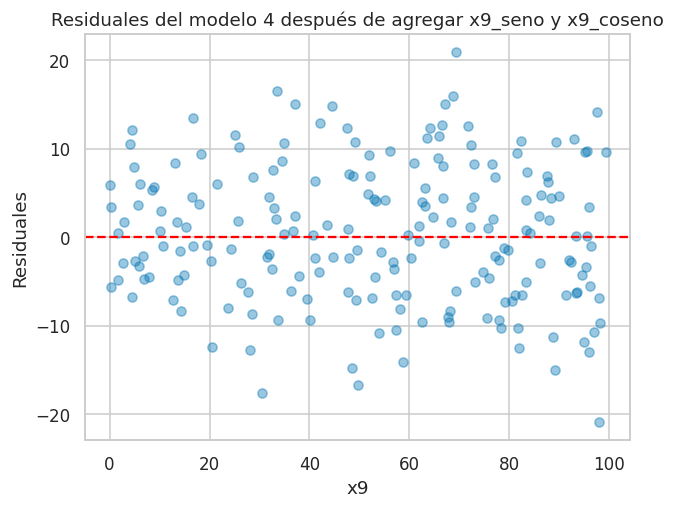

5 MSE: 55.54
Hipótesis: Distribuciones sesgadas.
MSE: [60.37] -> [55.54].Origen: observación propia.


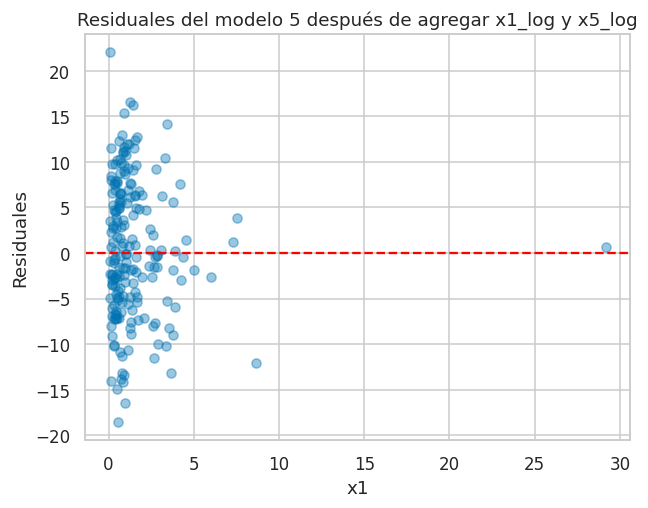

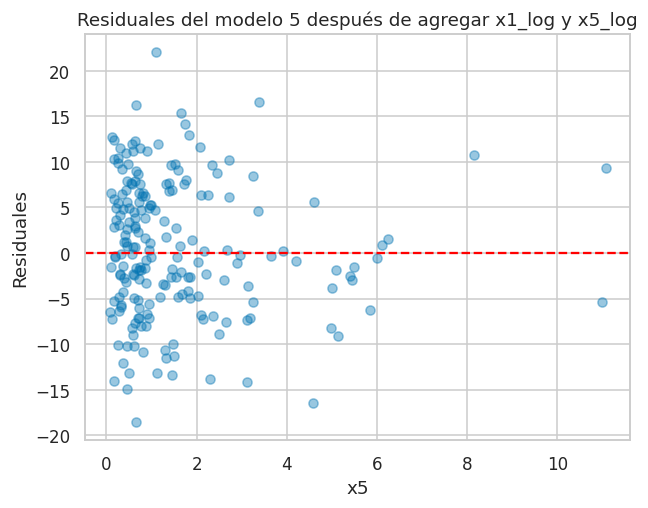

Me quedo con el quinto modelo
Primer cambio en MSE: -49.98%


In [30]:
# TODO: repitan el ciclo. Agreguen términos de uno en uno, graficando los residuales
# cada vez, hasta que ninguna gráfica tenga forma.
#
# Vayan guardando el MSE de cada paso: la bitácora de la Parte 5 lo pide.
#Cambio 2 
modelo_2, mse_2, residuales_2, _ = ajusta({
    "x6_cuadrado": lambda d: d["x6"] ** 2,
    "x2_cubo": lambda d: d["x2"] ** 3
})
print(f"2 MSE con x6^2 y x2^3: {mse_2:.2f}")
print("Hipótesis: faltaba una curvatura en x2.")
print("Gráfica: residuales contra x2, con forma de s volteada.")
print("Término: x2_cubo = x2^3.")
print("MSE: [72.88] -> [63.63].Origen: observación propia.")

plt.scatter(X_val["x2"], residuales_2, alpha=0.4)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("x2")
plt.ylabel("Residuales")
plt.title("Residuales del modelo 2 después de agregar x2^3")
plt.grid(True)
plt.show()

#Cambio 3
modelo_3, mse_3, residuales_3, _ = ajusta({
    "x6_cuadrado": lambda d: d["x6"] ** 2,
    "x2_cubo": lambda d: d["x2"] ** 3,
    "x9_cubo": lambda d: d["x9"] ** 3
})
print(f"3 MSE con x6^2, x2^3 y x9^3: {mse_3:.2f}")
print("Hipótesis: faltaba una curvatura en x9.")
print("Gráfica: residuales contra x9, con forma de s volteada.")
print("Término: x9_cubo = x9^3.")
print("MSE: [63.63] -> [64.57].Origen: observación propia.")

plt.scatter(X_val["x9"], residuales_3, alpha=0.4)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("x9")
plt.ylabel("Residuales")
plt.title("Residuales del modelo 3 después de agregar x9^3")
plt.grid(True)
plt.show()

#Cambio 4
modelo_4, mse_4, residuales_4, _ = ajusta({
    "x6_cuadrado": lambda d: d["x6"] ** 2,
    "x2_cubo": lambda d: d["x2"] ** 3,
    "x9_seno": lambda d: np.sin(2 * np.pi * d["x9"] / 280),
    "x9_coseno": lambda d: np.cos(2 * np.pi * d["x9"] / 280)
})
print(f"4 MSE con x6^2, x2^3, x9_seno y x9_coseno: {mse_4:.2f}")
print("Hipótesis: faltaba una curvatura en x9.")
print("Gráfica: residuales contra x9, con forma de s volteada.")
print("Término: seno y coseno de x9.")
print("MSE: [63.63] -> [60.37].Origen: observación propia.")

plt.scatter(X_val["x9"], residuales_4, alpha=0.4)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("x9")
plt.ylabel("Residuales")
plt.title("Residuales del modelo 4 después de agregar x9_seno y x9_coseno")
plt.grid(True)
plt.show()

modelo_5, mse_5, residuales_5, _ = ajusta({
    "x6_cuadrado": lambda d: d["x6"] ** 2,
    "x2_cubo": lambda d: d["x2"] ** 3,
    "x9_seno": lambda d: np.sin(2 * np.pi * d["x9"] / 280),
    "x9_coseno": lambda d: np.cos(2 * np.pi * d["x9"] / 280),
    "x1_log": lambda d: np.log1p(d["x1"]),
    "x5_log": lambda d: np.log1p(d["x5"]),
    "x4_seno": lambda d: np.sin(2 * np.pi * d["x4"] / 280),
    "x4_coseno": lambda d: np.cos(2 * np.pi * d["x4"] / 280),
    "x10_cubo": lambda d: d["x10"] ** 3,
    "x11_cubo": lambda d: d["x11"] ** 7,

})
print(f"5 MSE: {mse_5:.2f}")
print("Hipótesis: Distribuciones sesgadas.")
print("MSE: [60.37] -> [55.54].Origen: observación propia.")
#55.54

plt.scatter(X_val["x1"], residuales_5, alpha=0.4)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("x1")
plt.ylabel("Residuales")
plt.title("Residuales del modelo 5 después de agregar x1_log y x5_log")
plt.grid(True)
plt.show()

plt.scatter(X_val["x5"], residuales_5, alpha=0.4)
plt.axhline(0, color="red", linestyle="--")
plt.xlabel("x5")
plt.ylabel("Residuales")
plt.title("Residuales del modelo 5 después de agregar x1_log y x5_log")
plt.grid(True)
plt.show()

#Conclusión
print("Me quedo con el quinto modelo")
primer_cambio_en_mse=(55.54-111.04)/111.04*100
print(f"Primer cambio en MSE: {primer_cambio_en_mse:.2f}%")

---
## Parte 3. Lo que las gráficas de una variable no pueden ver

Cuando terminen la Parte 2 van a tener un modelo decente y, probablemente, ninguna
gráfica de residuales con forma evidente. Eso **no** significa que ya acabaron.

Hay efectos que son invisibles para cualquier gráfica de una sola variable: pueden tener
correlación cero con `y`, scatter plano y residual sin estructura, y aun así ser de los
efectos más grandes del modelo. Ninguna herramienta de la Parte 2 los encuentra.

Su trabajo aquí es averiguar **qué clase de efectos son, cómo se detectan, y si sus datos
tienen alguno**. Su IA les puede explicar la teoría si le hacen la pregunta correcta; sus
datos son los únicos que pueden contestar si aplica.

Una pista de método y ninguna de contenido: si mirar una variable a la vez no basta,
prueben mirando dos a la vez.

In [60]:
# TODO: exploren aquí.
#
# Son 66 pares de variables y no tienen que revisarlos a ciegas: usen lo que ya
# aprendieron en la Parte 2 para decidir por dónde empezar.
def grafica_interacciones(X_val, residuales, variable_base):
    
    otras_variables = [variable for variable in VARIABLES
        if variable != variable_base]

    plt.figure(figsize=(16, 12))

    for i, variable_color in enumerate(otras_variables):
        plt.subplot(3, 4, i + 1)
        puntos = plt.scatter(
            X_val[variable_base],
            residuales,
            c=X_val[variable_color],
            cmap="coolwarm",
            alpha=0.5)
        plt.axhline(
            0,
            color="black",
            linestyle="--")
        plt.xlabel(variable_base)
        plt.ylabel("Residuales")
        plt.title(f"{variable_base} × {variable_color}")
        plt.colorbar(puntos, label=variable_color)
        plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
#grafica_interacciones(X_val, residuales, "x1")
#grafica_interacciones(X_val, residuales, "x2")
#grafica_interacciones(X_val, residuales, "x3")
#grafica_interacciones(X_val, residuales, "x4")
#grafica_interacciones(X_val, residuales, "x5")
#grafica_interacciones(X_val, residuales, "x6")
#grafica_interacciones(X_val, residuales, "x7")
#grafica_interacciones(X_val, residuales, "x8")
#grafica_interacciones(X_val, residuales, "x9")
#grafica_interacciones(X_val, residuales, "x10")
#grafica_interacciones(X_val, residuales, "x11")
#grafica_interacciones(X_val, residuales, "x12")

In [28]:
# TODO: agreguen lo que hayan encontrado y midan.
modelo_6, mse_6, residuales_6, _ = ajusta({
    "x6_cuadrado": lambda d: d["x6"] ** 2,
    "x2_cubo": lambda d: d["x2"] ** 3,
    "x9_seno": lambda d: np.sin(2 * np.pi * d["x9"] / 280),
    "x9_coseno": lambda d: np.cos(2 * np.pi * d["x9"] / 280),
    "x1_log": lambda d: np.log1p(d["x1"]),
    "x5_log": lambda d: np.log1p(d["x5"]),
    "x4_seno": lambda d: np.sin(2 * np.pi * d["x4"] / 280),
    "x4_coseno": lambda d: np.cos(2 * np.pi * d["x4"] / 280),
    "x10_cubo": lambda d: d["x10"] ** 3,
    "x11_cubo": lambda d: d["x11"] ** 7,
    "x1_y_x7": lambda d: d["x1"] * d["x7"],
    "x1_y_x9": lambda d: d["x1"] * d["x9"],
    "x1_y_x10": lambda d: d["x1"] * d["x10"],
    "x2_y_x7": lambda d: d["x2"] * d["x7"],
    "x3_y_x12": lambda d: d["x3"] * d["x12"],
    "x4_y_x5": lambda d: d["x4"] * d["x5"],
    "x4_y_x7": lambda d: d["x4"] * d["x7"],
    "x4_y_x11": lambda d: d["x4"] * d["x11"],
    "x6_y_x11": lambda d: d["x6"] * d["x11"],
    "x7_y_x12": lambda d: d["x7"] * d["x12"],
    "x8_y_x9": lambda d: d["x8"] * d["x9"],
    "x8_y_x11": lambda d: d["x8"] * d["x11"],
    "x9_y_x12": lambda d: d["x9"] * d["x12"],
    "x11_y_x12": lambda d: d["x11"] * d["x12"]
})
print(f"5 MSE con cambio 6: {mse_6:.2f}")
print("MSE: [55.54] -> [37.48]")
segundo_cambio_en_mse=(37.48-111.04)/111.04*100
print(f"Segundo cambio en MSE: {segundo_cambio_en_mse:.2f}%")
#1 y 7, 1 y 9, 1 y 10, 2 y 7, 
#3 y 12, 4 y 5, 4 y 7,4 y 11,6 y 11, 7 y 12, 8 y 9
#9 y 12, 11 y 12

5 MSE con cambio 6: 37.48
MSE: [55.54] -> [37.48]
Segundo cambio en MSE: -66.25%


---
## Parte 4. El otro camino: fuerza bruta

Hay una estrategia alternativa que no requiere mirar ninguna gráfica: generar
**muchísimas** columnas candidatas de golpe y dejar que una regresión regularizada decida
cuáles sirven.

`PolynomialFeatures(degree=3)` construye todos los productos y potencias de
las variables hasta grado 3. Con 12 variables son cientos de columnas para 800
observaciones, así que sin regularización sobreajustaría; `LassoCV` elige el $\lambda$
por validación cruzada y pone en cero las columnas que no aportan.

Impleméntenlo y **compárenlo contra su modelo de la Parte 3**.

In [57]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# TODO: camino B. Pipeline sugerido:
#   PolynomialFeatures(degree=3) -> StandardScaler -> LassoCV
#
# Estandaricen antes del Lasso: la penalización castiga coeficientes grandes, y sin
# estandarizar "grande" depende de las unidades de cada columna.
#
# Reporten el MSE de validación y cuántas columnas dejó distintas de cero.

#genera columnas polinomiales de grado 3
poli= PolynomialFeatures(degree=3, include_bias=False)

#escala columnas
esc=StandardScaler()

#ajusta lasso con validación cruzada
lasso=LassoCV(cv=5, random_state=SEMILLA).fit(esc.fit_transform(poli.fit_transform(X_train)), y_train)

X_train_poli = poli.fit_transform(X_train)
X_val_poli = poli.transform(X_val)

X_train_poli = esc.fit_transform(X_train_poli)
X_val_poli = esc.transform(X_val_poli)

lasso.fit(X_train_poli, y_train)

pred_val_poli = lasso.predict(X_val_poli)
mse_poli = mean_squared_error(y_val, pred_val_poli)

coef = lasso.coef_
n_no_cero = np.sum(np.abs(coef) > 1e-8)

print(f"MSE de validación con fuerza bruta: {mse_poli:.2f}")
print(f"Columnas distintas de cero: {n_no_cero}")
print(f"R^2 en validación: {lasso.score(X_val_poli, y_val):.3f}")

/workspaces/mineria_datos/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.248e+01, tolerance: 7.520e+00
  model = cd_fast.enet_coordinate_descent_gram(
/workspaces/mineria_datos/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.411e+01, tolerance: 7.520e+00
  model = cd_fast.enet_coordinate_descent_gram(
/workspaces/mineria_datos/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or cons

MSE de validación con fuerza bruta: 51.58
Columnas distintas de cero: 33
R^2 en validación: 0.673


/workspaces/mineria_datos/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.057e+01, tolerance: 8.240e+00
  model = cd_fast.enet_coordinate_descent_gram(
/workspaces/mineria_datos/.venv/lib/python3.13/site-packages/sklearn/linear_model/_coordinate_descent.py:701: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.028e+01, tolerance: 8.240e+00
  model = cd_fast.enet_coordinate_descent_gram(


### 4.1 La pregunta que vale la respuesta

Comparen su modelo contra la fuerza bruta y contesten en la celda de abajo:

1. ¿Cuál dio menor MSE de validación? 
2. Si su modelo guiado por gráficas le ganó a la fuerza bruta: **¿por qué?** Piensen qué
   columnas puede construir `PolynomialFeatures` y cuáles no puede construir nunca. 
3. Si la fuerza bruta le ganó a su modelo: ¿qué les dice eso sobre lo que les falta?
4. ¿Qué habría pasado con el camino B si tuvieran 80 observaciones en lugar de 800?

Mi modelo manual obtuvo menor MSE porque la estructura real de los datos era relativamente clara y los términos que detecté con los residuales capturaban bien el patrón relevante. La fuerza bruta construyó un espacio mucho más amplio de términos, incluyendo potencias e interacciones poco informativas, y el Lasso tuvo menos claridad para distinguir señal real de ruido. Con 80 observaciones, ese camino habría empeorado por el mayor riesgo de overfitting y selección inestable de variables.

---
## Parte 5. Bitácora

Esta parte vale tanto como el MSE. Una fila por hipótesis, **incluidas las que
fallaron** — sobre todo las que fallaron.

Si no tienen al menos un callejón sin salida documentado, esta parte vale cero: significa
que no exploraron, o que le pidieron la respuesta a alguien.

| # | Hipótesis | Gráfica que la probó | Término agregado | MSE antes → después | ¿La sugirió la IA o yo? |
|---|---|---|---|---|---|
| 1 | | | | | |
| 2 | | | | | |
| 3 | | | | | |
| 4 | | | | | |
| 5 | | | | | |
| 6 | | | | | |
| 7 | | | | | |
| 8 | | | | | |

### 5.1 Su modelo final, en palabras

Escriban la función que creen que genera los datos. Algo de la forma
`y = a + b*x? + c*f(x?) + ... + ruido`, con los nombres de sus variables.

*(Su respuesta aquí)*

### 5.2 Dónde se equivocó su IA

Cuenten **un** momento concreto en el que la IA les dijo algo que resultó falso o
inútil para sus datos, y cómo lo detectaron. Si dicen que nunca falló, es que no la
interrogaron lo suficiente.

*(Su respuesta aquí)*

### 5.3 Cuándo pararon y por qué

`/validar` les dice cuál es el MSE meta: el error del modelo bien especificado, que es
**ruido puro** y no se puede bajar. ¿Qué tan cerca quedaron? ¿Cómo supieron que ya no
valía la pena seguir?

*(Su respuesta aquí)*

---
## Entrega

Corran la celda de abajo: ajusta **su modelo final** usando *todo* `train` (ya no solo la
partición de entrenamiento — con más datos, mejores coeficientes) y escribe el archivo de
predicciones en el lugar exacto donde el bot lo busca.

In [31]:
# TODO: pongan aquí las columnas derivadas de su modelo final, con el mismo formato
# que usaron en `ajusta`. Si su modelo final es el baseline crudo, déjenlo vacío.
MI_MODELO = {
    "x6_cuadrado": lambda d: d["x6"] ** 2,
    "x2_cubo": lambda d: d["x2"] ** 3,
    "x9_seno": lambda d: np.sin(2 * np.pi * d["x9"] / 280),
    "x9_coseno": lambda d: np.cos(2 * np.pi * d["x9"] / 280),
    "x1_log": lambda d: np.log1p(d["x1"]),
    "x5_log": lambda d: np.log1p(d["x5"]),
    "x4_seno": lambda d: np.sin(2 * np.pi * d["x4"] / 280),
    "x4_coseno": lambda d: np.cos(2 * np.pi * d["x4"] / 280),
    "x10_cubo": lambda d: d["x10"] ** 3,
    "x11_cubo": lambda d: d["x11"] ** 7,
    "x1_y_x7": lambda d: d["x1"] * d["x7"],
    "x1_y_x9": lambda d: d["x1"] * d["x9"],
    "x1_y_x10": lambda d: d["x1"] * d["x10"],
    "x2_y_x7": lambda d: d["x2"] * d["x7"],
    "x3_y_x12": lambda d: d["x3"] * d["x12"],
    "x4_y_x5": lambda d: d["x4"] * d["x5"],
    "x4_y_x7": lambda d: d["x4"] * d["x7"],
    "x4_y_x11": lambda d: d["x4"] * d["x11"],
    "x6_y_x11": lambda d: d["x6"] * d["x11"],
    "x7_y_x12": lambda d: d["x7"] * d["x12"],
    "x8_y_x9": lambda d: d["x8"] * d["x9"],
    "x8_y_x11": lambda d: d["x8"] * d["x11"],
    "x9_y_x12": lambda d: d["x9"] * d["x12"],
    "x11_y_x12": lambda d: d["x11"] * d["x12"]
}


def construye_final(df):
    salida = df[VARIABLES].copy()
    for nombre, f in MI_MODELO.items():
        salida[nombre] = f(df)
    return salida


# La estimación honesta de su MSE: ajustada SOLO en la partición de entrenamiento
# y medida en validación. Este es el número que deberían creer.
_, mse_estimado, _, _ = ajusta(MI_MODELO)
print(f"MSE estimado (ajustado en train, medido en validación): {mse_estimado:.2f}")

# Y ahora sí, el modelo que entregan: reajustado con TODO train, porque con 800
# observaciones en lugar de 600 los coeficientes salen mejores. Ojo: a este modelo
# ya no se le puede medir el MSE en validación, porque validación fue parte de su
# entrenamiento. Medirlo ahí daría un número optimista y falso.
modelo_final = LinearRegression().fit(construye_final(train), train["y"])
predicciones = modelo_final.predict(construye_final(test))

assert len(predicciones) == 400, f"deben ser 400 predicciones, hay {len(predicciones)}"
assert np.isfinite(predicciones).all(), "hay predicciones NaN o infinitas"

destino = RAIZ / "entregas/tarea-01" / CARPETA
destino.mkdir(parents=True, exist_ok=True)
pd.DataFrame({"y": predicciones}).to_csv(destino / "predicciones.csv", index=False)

print(f"\nEscrito: {destino.relative_to(RAIZ)}/predicciones.csv")
print(f"{len(predicciones)} predicciones, rango {predicciones.min():.2f} a {predicciones.max():.2f}")

MSE estimado (ajustado en train, medido en validación): 37.48

Escrito: entregas/tarea-01/v67e9ec7a/predicciones.csv
400 predicciones, rango -25.37 a 41.25


### Los últimos pasos

El detalle está en **`tareas/tarea_01_README.md`**, que trae dos caminos: hacer todo en
**GitHub Codespaces** (en el navegador, sin instalar nada) o en **su computadora**. Los
dos son válidos; si nunca han configurado Python, vayan por Codespaces.

En resumen, igual en los dos casos:

1. Hagan commit de este notebook **y** de su `predicciones.csv`.
2. `git push` a su rama en su fork.
3. Abran un Pull Request al repo del curso.
4. Comenten **`/validar`** en el PR. Les confirma el formato y les dice su MSE objetivo,
   sin gastar intento. Úsenlo siempre antes de calificar.
5. Cuando estén listos, comenten **`/calificar`**. Eso sí gasta uno de sus 3 intentos.

Si `/validar` les marca un error, corrijan, hagan push otra vez y vuelvan a comentar
`/validar`. Las veces que quieran.